In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

current_dir = os.getcwd()
if not os.path.exists(os.path.join(current_dir, 'src')):
    root_dir = os.path.abspath(os.path.join(current_dir, '..'))
    os.chdir(root_dir)

sns.set_theme(style="ticks", context="paper", font_scale=1.2)
plt.rcParams.update({
    'figure.dpi': 300,           
    'axes.spines.top': False,     
    'axes.spines.right': False,  
    'font.family': 'serif'        
})

COLORS = ['#3498db', '#e74c3c']

In [3]:
RAW_DATA_PATH = os.path.join(os.getcwd(), "data", "raw", "sms_spam_indo.csv")
df = pd.read_csv(RAW_DATA_PATH)

total_rows = len(df)
missing_values = df.isnull().sum().sum()
duplicates = df.duplicated(subset=['Pesan']).sum()
class_counts = df['Kategori'].value_counts()
class_ratios = df['Kategori'].value_counts(normalize=True) * 100

eda_summary = pd.DataFrame({
    'Metrik': ['Total Sample', 'Missing Value', 'Duplicate', 'Ham Category', 'Spam Category'],
    'Nilai': [total_rows, missing_values, duplicates, class_counts.get('normal', 0), class_counts.get('spam', 0)],
    'Persentase': ['100%', f"{(missing_values/total_rows)*100:.2f}%", f"{(duplicates/total_rows)*100:.2f}%", f"{class_ratios.get('normal', 0):.1f}%", f"{class_ratios.get('spam', 0):.1f}%"]
})

display(eda_summary)

,Metrik,Nilai,Persentase
0,Total Sample,1143,100%
1,Missing Value,0,0.00%
2,Duplicate,1,0.09%
3,Ham Category,0,0.0%
4,Spam Category,574,50.2%


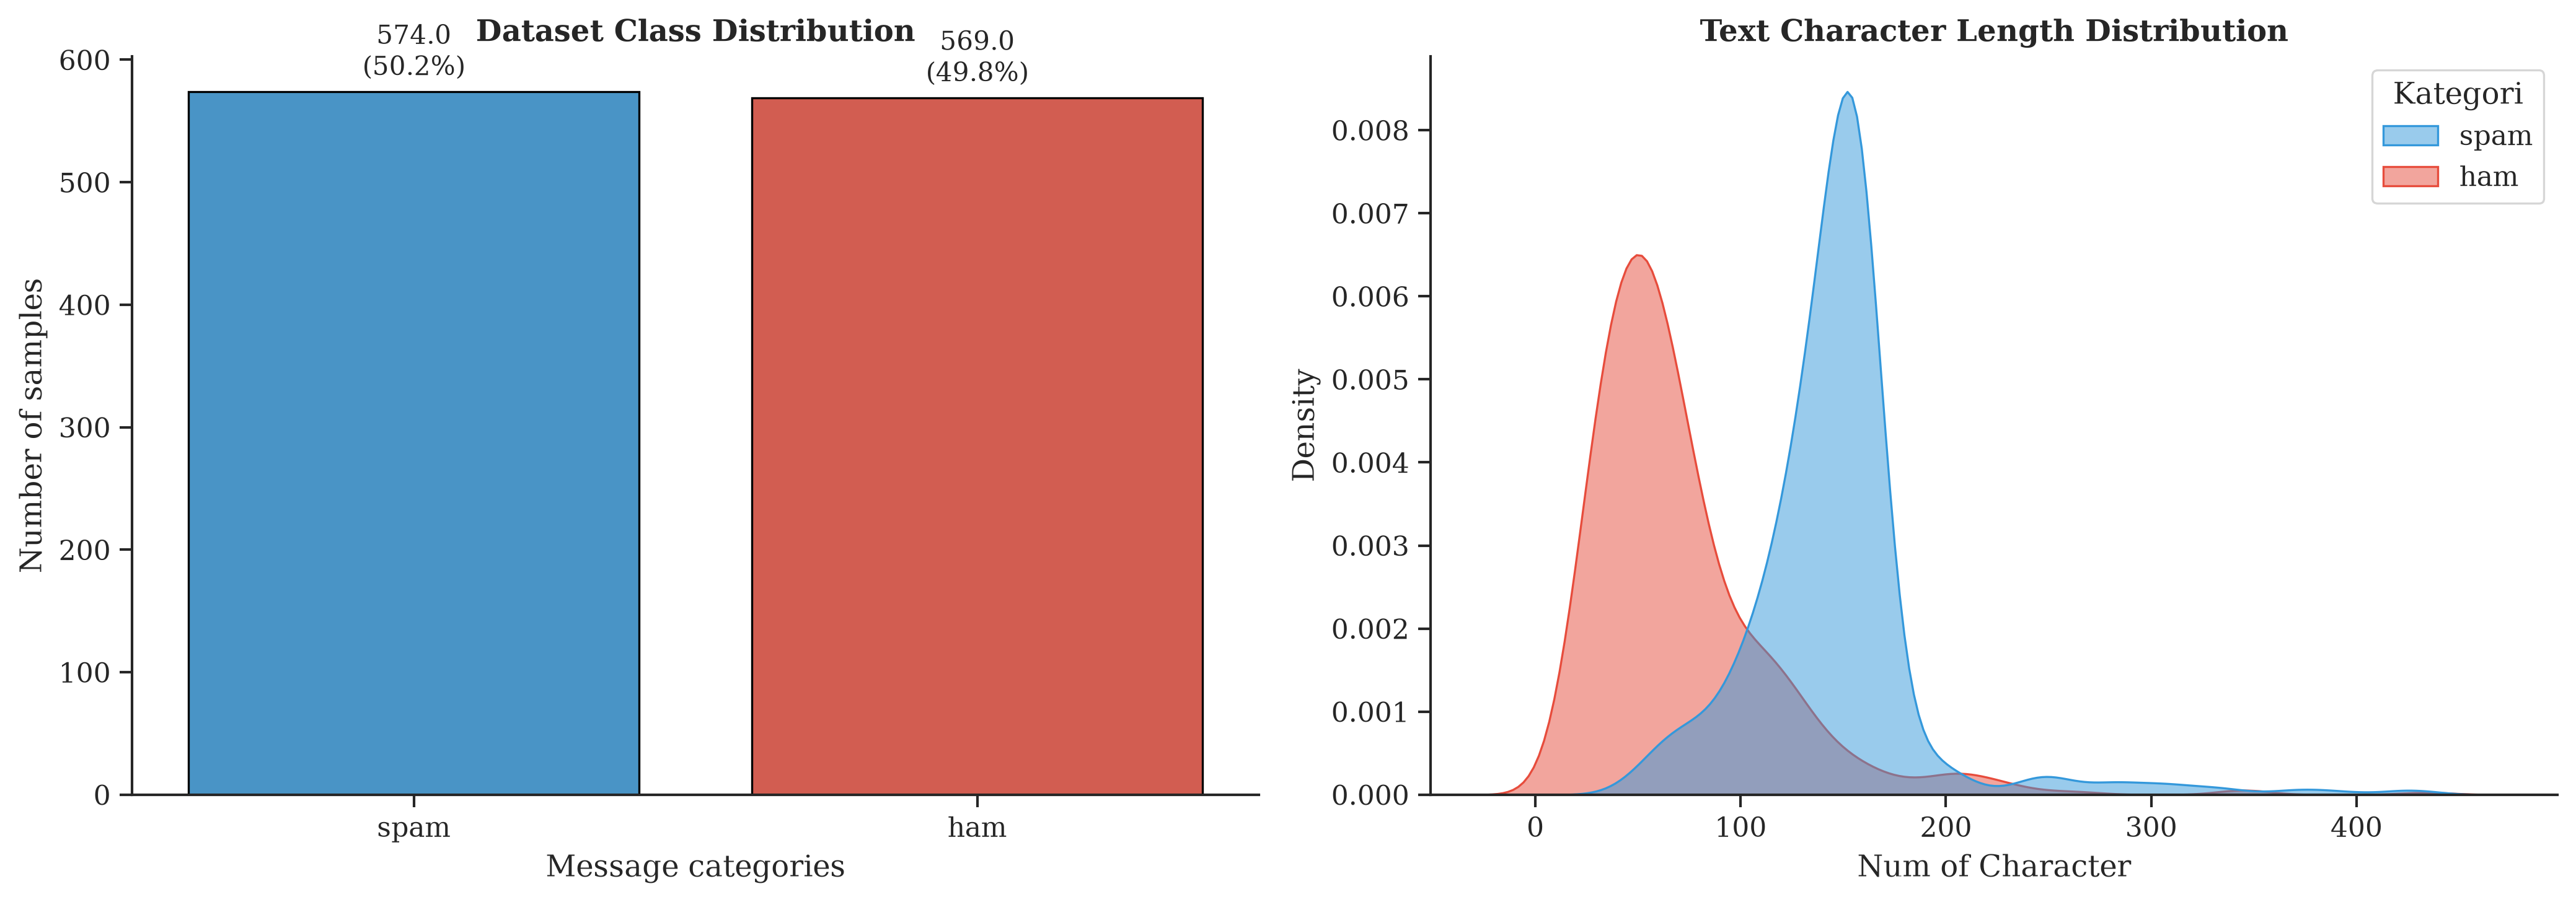

Karakter                          Kata                     
             mean median min  max    std   mean median min max   std
Kategori                                                            
ham         70.54   59.0  13  434  46.23  12.12   11.0   2  63  7.23
spam       146.60  149.0  46  431  44.19  21.22   20.0   5  62  6.99

In [4]:
df['Karakter'] = df['Pesan'].apply(len)
df['Kata'] = df['Pesan'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='Kategori', hue='Kategori', palette=COLORS, ax=axes[0], edgecolor='black')
axes[0].set_title('Dataset Class Distribution', fontweight='bold')
axes[0].set_ylabel('Number of samples')
axes[0].set_xlabel('Message categories')

for p in axes[0].patches:
    height = p.get_height()
    axes[0].annotate(f'{height}\n({(height/total_rows)*100:.1f}%)', 
                     xy=(p.get_x() + p.get_width() / 2, height),
                     xytext=(0, 3), textcoords="offset points", 
                     ha='center', va='bottom', fontsize=10)

sns.kdeplot(data=df, x='Karakter', hue='Kategori', fill=True, palette=COLORS, ax=axes[1], alpha=0.5)
axes[1].set_title('Text Character Length Distribution', fontweight='bold')
axes[1].set_ylabel('Density')
axes[1].set_xlabel('Num of Character')

plt.tight_layout()
plt.show()

text_stats = df.groupby('Kategori')[['Karakter', 'Kata']].agg(['mean', 'median', 'min', 'max', 'std']).round(2)
display(text_stats)

In [5]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_classification(train_df, test_df, model_name, technique):
    """
    Melatih XGBoost pada data latih dan mengujinya pada data uji
    """
    X_train_text = train_df['Pesan'].astype(str)
    X_test_text = test_df['Pesan'].astype(str)
    
    label_map = {'ham': 0, 'normal': 0, 'spam': 1}
    y_train = train_df['Kategori'].map(label_map).values
    y_test = test_df['Kategori'].map(label_map).values
    
    vectorizer = TfidfVectorizer(max_features=5000)
    X_train_tfidf = vectorizer.fit_transform(X_train_text).toarray()
    X_test_tfidf = vectorizer.transform(X_test_text).toarray()
    
    xgb = XGBClassifier(
        n_estimators=100, 
        max_depth=6, 
        learning_rate=0.1, 
        random_state=42,
        eval_metric='logloss'
    )
    
    xgb.fit(X_train_tfidf, y_train)
    
    y_pred = xgb.predict(X_test_tfidf)
    y_prob = xgb.predict_proba(X_test_tfidf)[:, 1]
    
    return {
        'Model': model_name,
        'Technique': technique,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'y_test': y_test,    
        'y_prob': y_prob     
    }

Ditemukan 12 file dataset di 'c:\LLM_scam\code\data\augmented\20260902141148\merged\balanced'.
Semua grafik disimpan secara otomatis ke: c:\LLM_scam\code\data\augmented\20260902141148\merged\balanced\visualization



C:\Users\10\AppData\Local\Temp\ipykernel_21956\2340152992.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_plot, x='Kategori', ax=axes[0], palette=['#3498db', '#e74c3c'], edgecolor='black')


-> Menampilkan sampel distribusi untuk: balanced_GPT_3.5_Turbo_few-shot.csv


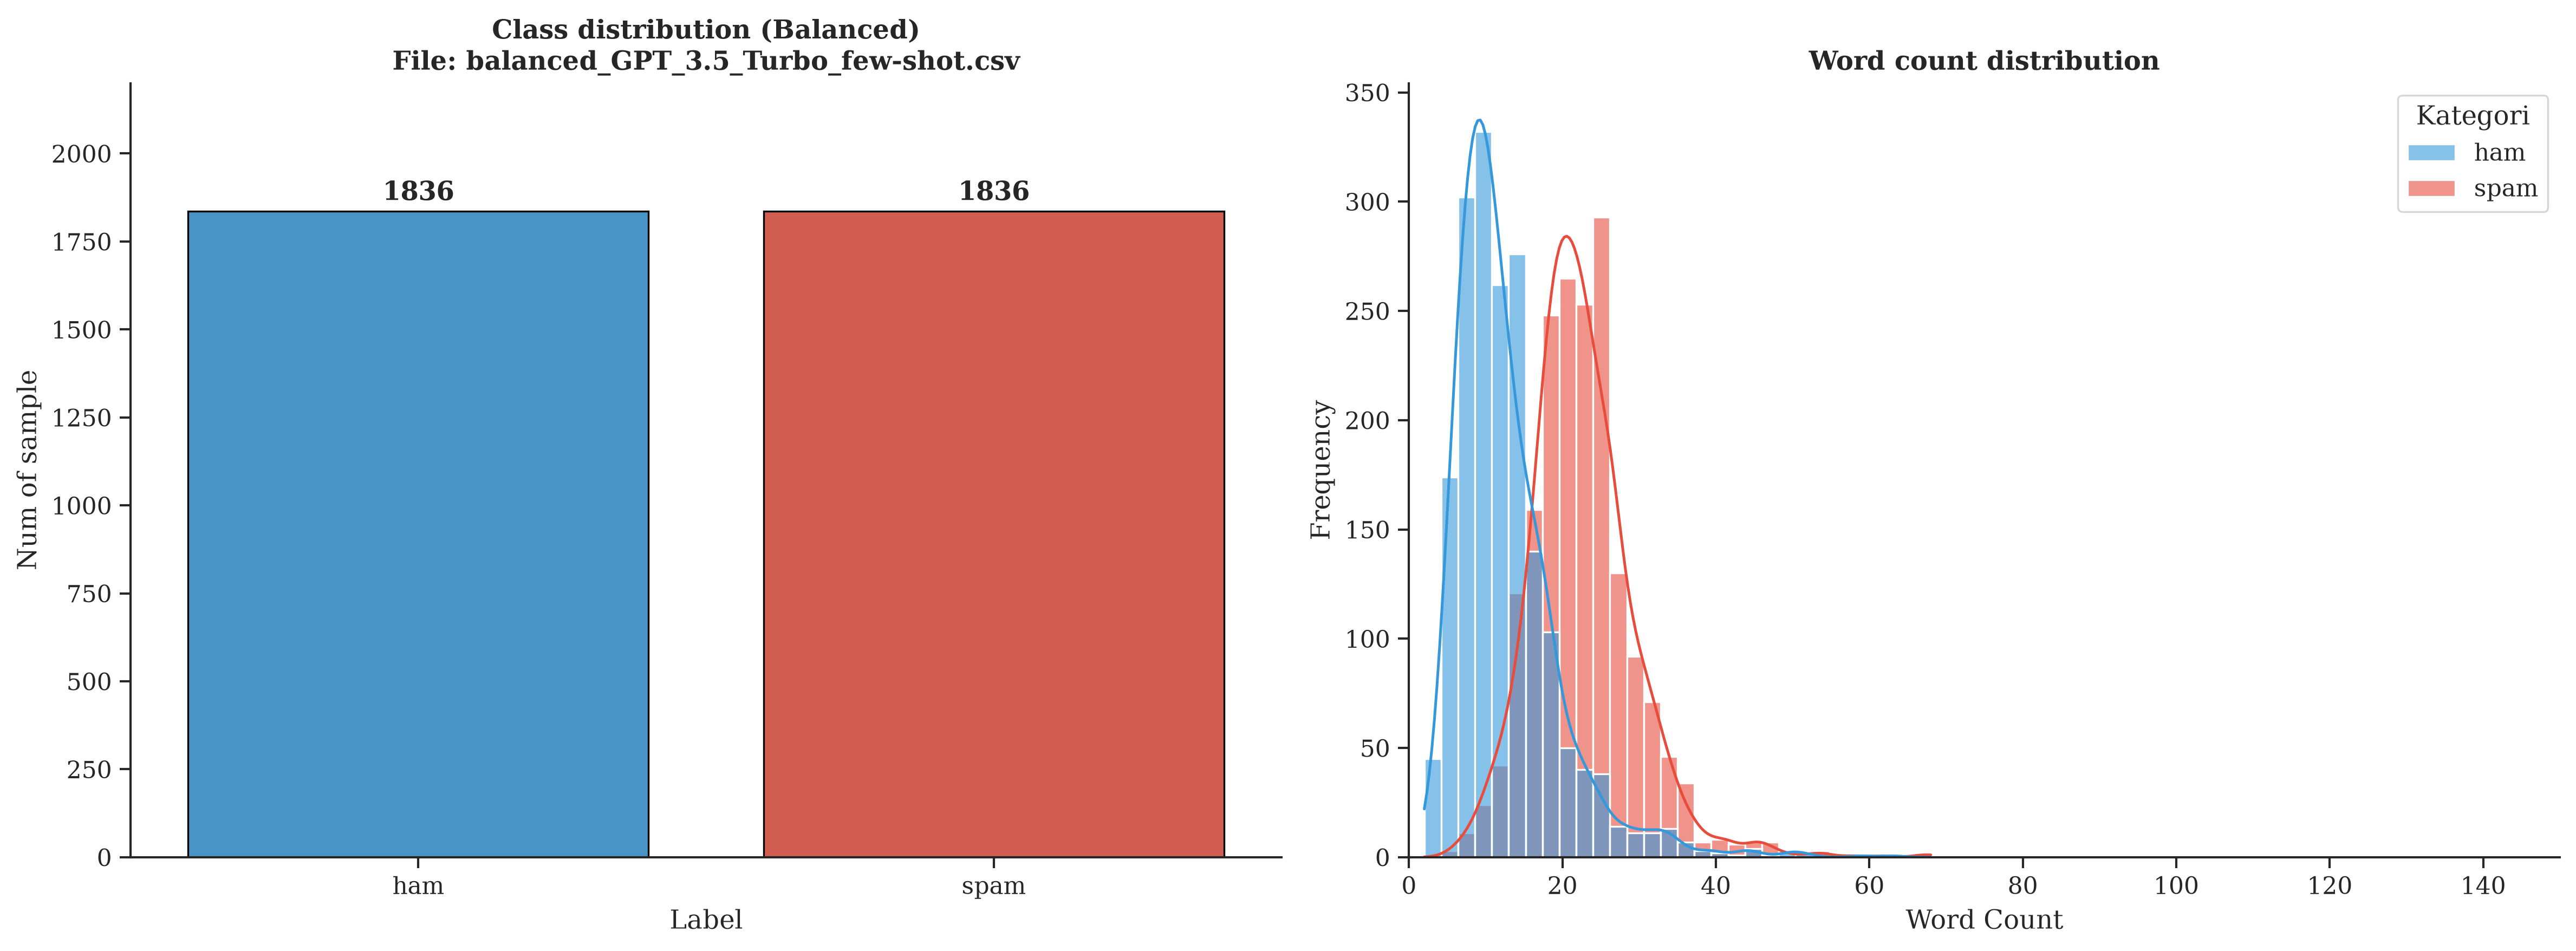

,count,mean,std,min,25%,50%,75%,max
Kategori,,,,,,,,
ham,1836.0,12.55,6.76,2.0,8.0,11.0,15.0,63.0
spam,1836.0,22.60,6.76,5.0,18.0,22.0,26.0,68.0


C:\Users\10\AppData\Local\Temp\ipykernel_21956\2340152992.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_plot, x='Kategori', ax=axes[0], palette=['#3498db', '#e74c3c'], edgecolor='black')
C:\Users\10\AppData\Local\Temp\ipykernel_21956\2340152992.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_plot, x='Kategori', ax=axes[0], palette=['#3498db', '#e74c3c'], edgecolor='black')
C:\Users\10\AppData\Local\Temp\ipykernel_21956\2340152992.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_plot, x='Kategori'


-> Menampilkan Grafik Komparasi Rata-rata Kata:


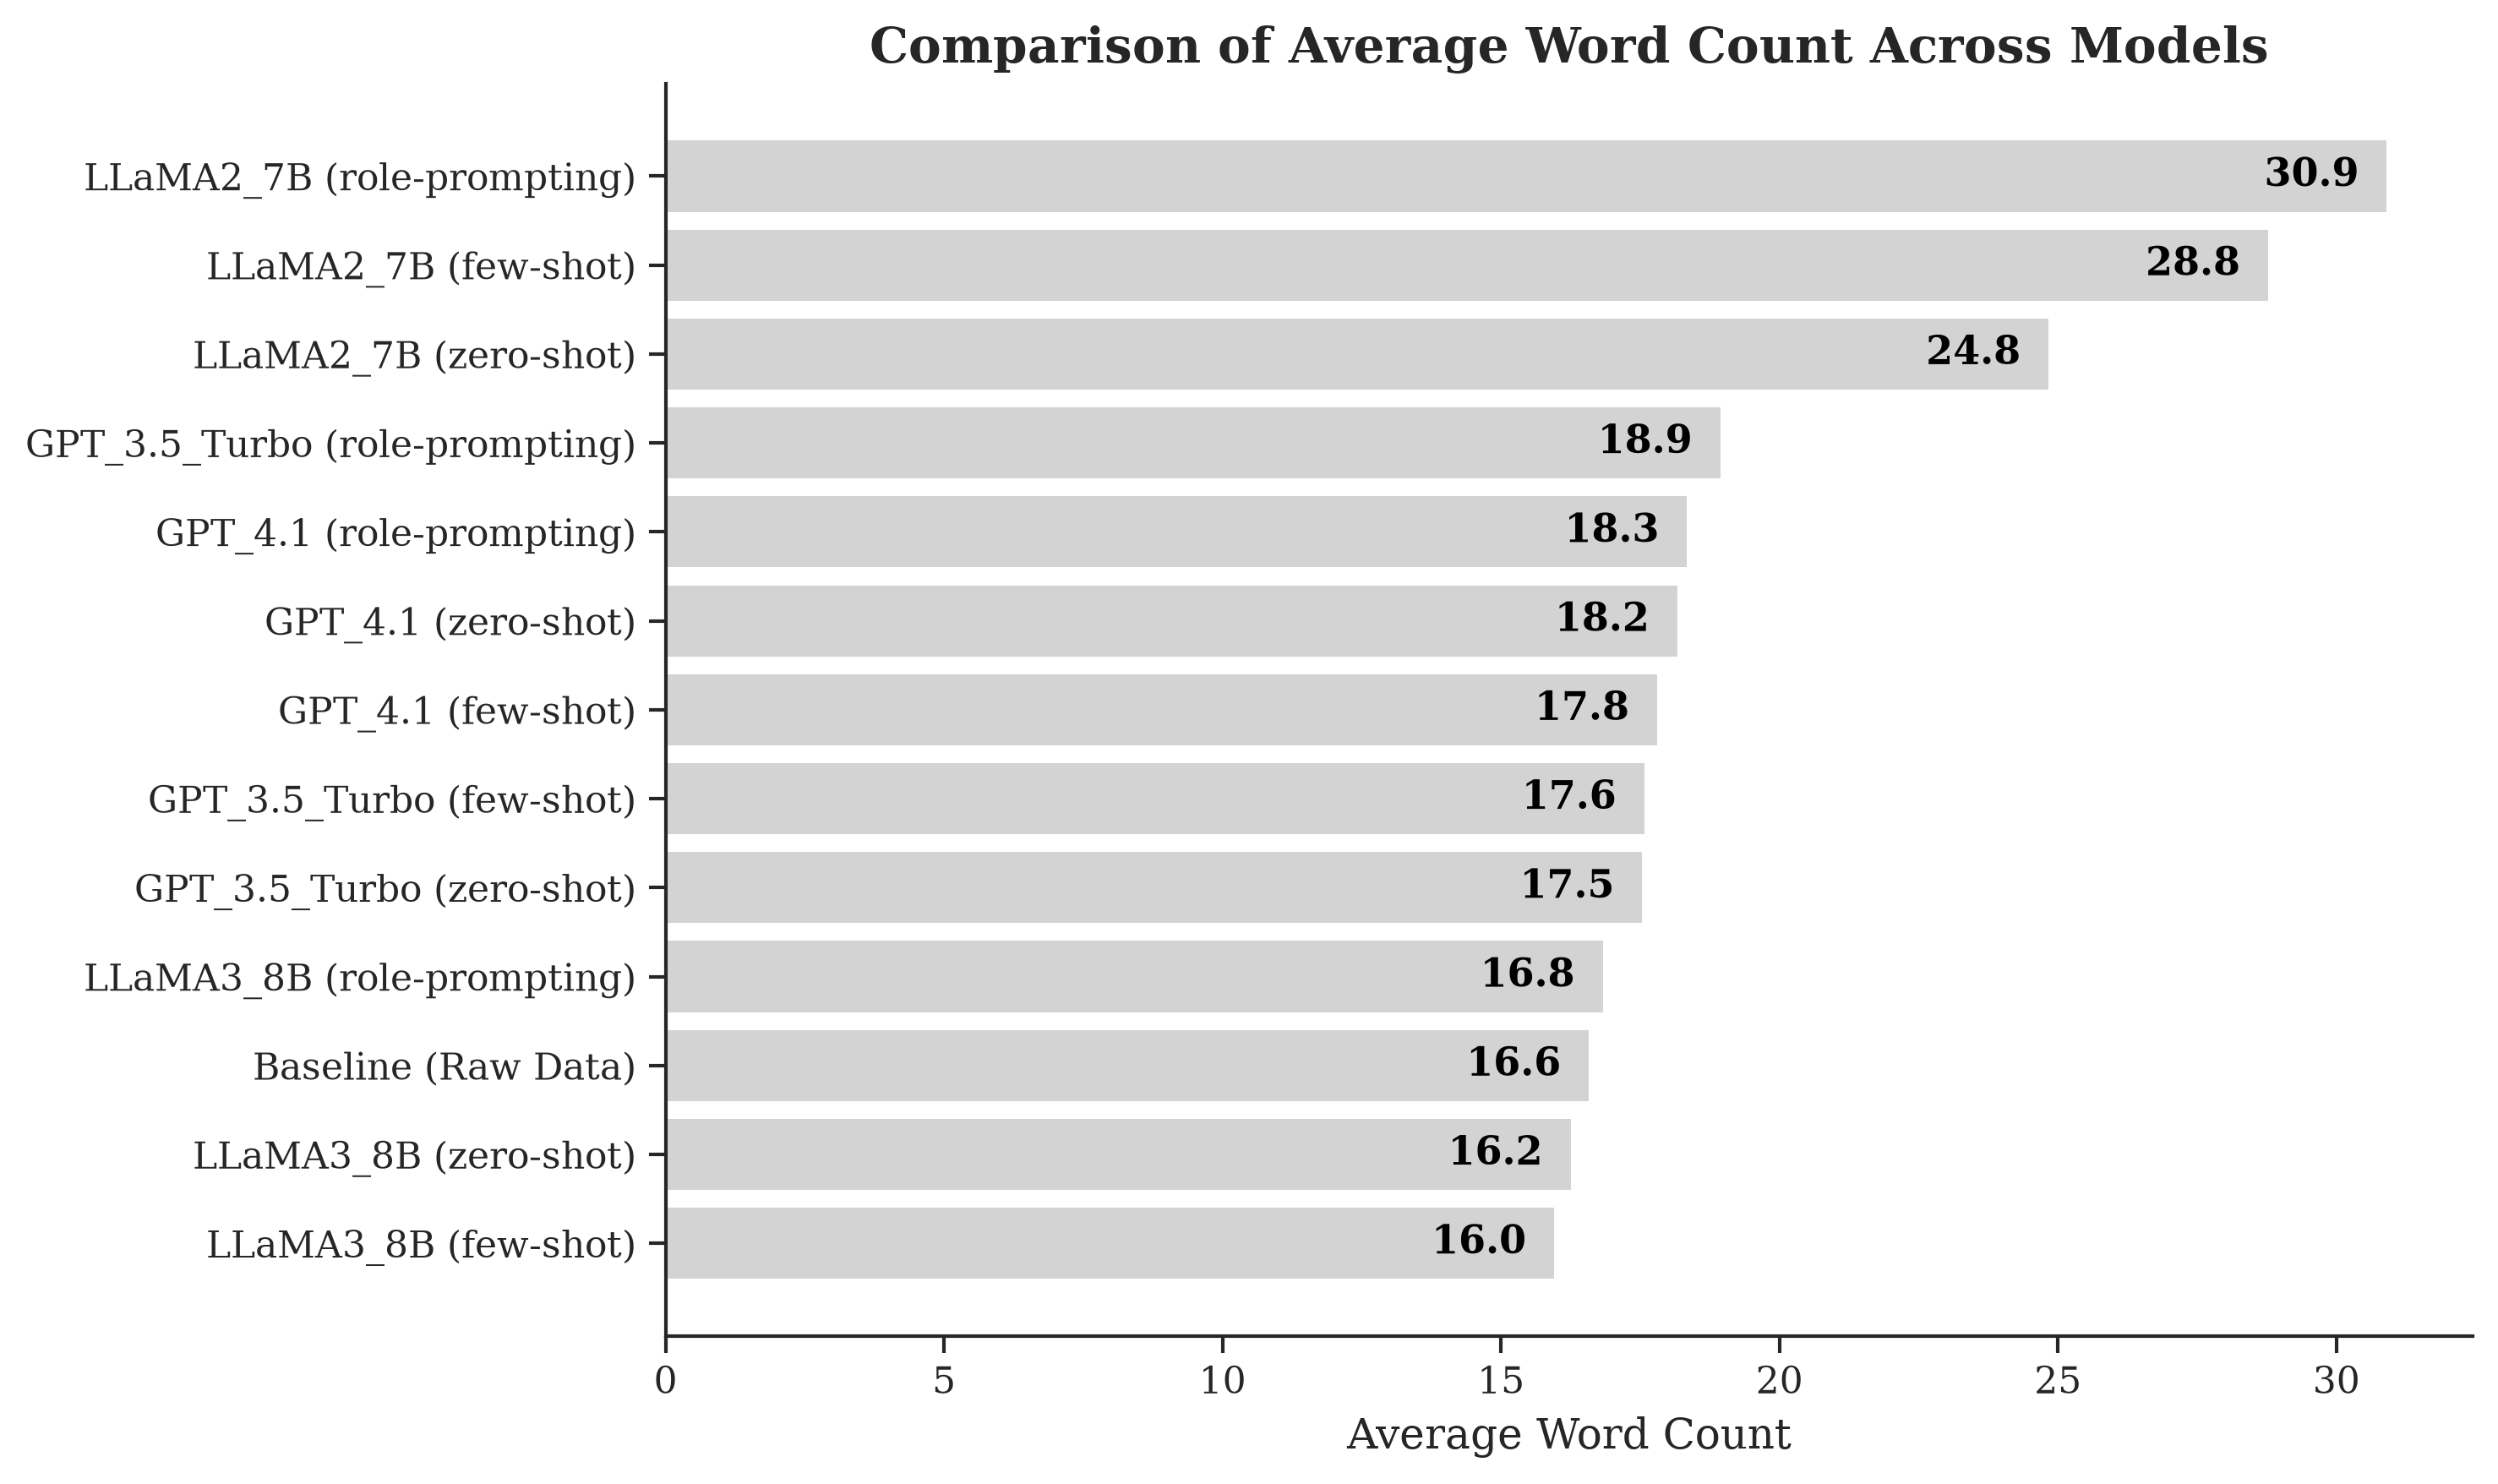

In [9]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

TIMESTAMP_FOLDER = "20260902141148" 
USE_BALANCED_DATA = True

if USE_BALANCED_DATA:
    target_dir = os.path.join(root_dir, "data", "augmented", TIMESTAMP_FOLDER, "merged", "balanced")
    file_pattern = "balanced_*.csv"
    prefix_to_remove = "balanced_"
else:
    target_dir = os.path.join(root_dir, "data", "augmented", TIMESTAMP_FOLDER, "merged")
    file_pattern = "merged_*.csv"
    prefix_to_remove = "merged_"

visualization_dir = os.path.join(target_dir, "visualization")
os.makedirs(visualization_dir, exist_ok=True)

target_files = []
avg_word_counts = [] 

if not os.path.exists(target_dir):
    print(f"Error: Directory not found -> {target_dir}")
else:
    target_files = glob.glob(os.path.join(target_dir, file_pattern))
    print(f"Ditemukan {len(target_files)} file dataset di '{target_dir}'.")
    print(f"Semua grafik disimpan secara otomatis ke: {visualization_dir}\n")

    if len(target_files) > 0:
        TRAIN_DATA_PATH = os.path.join(root_dir, "data", "raw", "train_data.csv")
        df_baseline = pd.read_csv(TRAIN_DATA_PATH).dropna(subset=['Pesan', 'Kategori'])
        df_baseline['Word_Count'] = df_baseline['Pesan'].apply(lambda x: len(str(x).split()))
        avg_word_counts.append({'Model': 'Baseline (Raw Data)', 'Avg_WC': df_baseline['Word_Count'].mean()})
        
        for i, file_path in enumerate(target_files):
            file_name = os.path.basename(file_path)
            clean_name = file_name.replace(".csv", "").replace(prefix_to_remove, "")
            
            parts = clean_name.split("_")
            technique = parts[-1] 
            model_name = "_".join(parts[:-1])
            label_name = f"{model_name} ({technique})"
            
            df_plot = pd.read_csv(file_path).dropna(subset=['Pesan', 'Kategori'])
            df_plot['Word_Count'] = df_plot['Pesan'].apply(lambda x: len(str(x).split()))
            
            avg_word_counts.append({'Model': label_name, 'Avg_WC': df_plot['Word_Count'].mean()})

            fig, axes = plt.subplots(1, 2, figsize=(16, 6))
            status_text = "Balanced" if USE_BALANCED_DATA else "Unbalanced"

            sns.countplot(data=df_plot, x='Kategori', ax=axes[0], palette=['#3498db', '#e74c3c'], edgecolor='black')
            axes[0].set_title(f"Class distribution ({status_text})\nFile: {file_name}", fontweight='bold')
            axes[0].set_ylabel("Num of sample")
            axes[0].set_xlabel("Label")
            axes[0].set_ylim(0, 2200)

            for p in axes[0].patches:
                height = p.get_height()
                axes[0].annotate(f'{int(height)}', xy=(p.get_x() + p.get_width() / 2, height),
                                 xytext=(0, 5), textcoords="offset points", ha='center', fontweight='bold')

            sns.histplot(data=df_plot, x='Word_Count', hue='Kategori', kde=True, ax=axes[1], 
                         palette=['#3498db', '#e74c3c'], bins=30, alpha=0.6)
            axes[1].set_title("Word count distribution", fontweight='bold')
            axes[1].set_ylabel("Frequency")
            axes[1].set_xlabel("Word Count")

            axes[1].set_xlim(0, 150) 
            
            plt.tight_layout()
            
            save_path = os.path.join(visualization_dir, f"{clean_name}.png")
            plt.savefig(save_path, dpi=150)
            
            if i == 0:
                print(f"-> Menampilkan sampel distribusi untuk: {file_name}")
                plt.show()
                display(df_plot.groupby('Kategori')['Word_Count'].describe().round(2))
            else:
                plt.close(fig) 

        df_avg = pd.DataFrame(avg_word_counts)
        df_avg = df_avg.sort_values(by='Avg_WC', ascending=True)

        plt.figure(figsize=(10, 6))
        
        bars = plt.barh(df_avg['Model'], df_avg['Avg_WC'], color='#d3d3d3', edgecolor='none')
        
        plt.title("Comparison of Average Word Count Across Models", fontweight='bold', fontsize=14)
        plt.xlabel("Average Word Count", fontsize=12)
        
        for bar in bars:
            width = bar.get_width()
            plt.text(width - 0.5, 
                     bar.get_y() + bar.get_height()/2, 
                     f'{width:.1f}', 
                     ha='right', va='center', fontweight='bold', color='black', fontsize=11)

        plt.tight_layout()
        
        comparison_path = os.path.join(visualization_dir, "Comparison_Average_WordCount.png")
        plt.savefig(comparison_path, dpi=300)
        
        print("\n-> Menampilkan Grafik Komparasi Rata-rata Kata:")
        plt.show()

    else:
        print("CSV file not found")

In [6]:
if 'target_files' in locals() and len(target_files) > 0:
    TRAIN_DATA_PATH = os.path.join(root_dir, "data", "raw", "train_data.csv")
    TEST_DATA_PATH = os.path.join(root_dir, "data", "raw", "test_data.csv")

    train_baseline_df = pd.read_csv(TRAIN_DATA_PATH).dropna(subset=['Pesan', 'Kategori'])
    test_df = pd.read_csv(TEST_DATA_PATH).dropna(subset=['Pesan', 'Kategori'])

    print("Mengevaluasi Baseline...")
    results_list = [evaluate_classification(train_baseline_df, test_df, 'Baseline', 'None')]

    print("\nMemulai evaluasi pada dataset LLM...")
    for file_path in target_files:
        file_name = os.path.basename(file_path).replace(".csv", "").replace(prefix_to_remove, "")
        parts = file_name.split("_")
        technique = parts[-1] 
        model_name = "_".join(parts[:-1])
        
        df_train = pd.read_csv(file_path).dropna(subset=['Pesan', 'Kategori'])
        
        print(f"-> Memproses: {model_name} | {technique}")
        res = evaluate_classification(df_train, test_df, model_name, technique)
        results_list.append(res)

    df_results = pd.DataFrame(results_list)
    cols = ['Model', 'Technique', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'y_test', 'y_prob']
    df_results = df_results[cols]

    display_df = df_results.drop(columns=['y_test', 'y_prob'])
    display(display_df.round(4).style.background_gradient(subset=['F1-Score', 'Recall', 'ROC-AUC'], cmap='Blues'))
else:
    print("Eksekusi dibatalkan: Tidak ada data file target yang diteruskan dari cell sebelumnya.")

Mengevaluasi Baseline...

Memulai evaluasi pada dataset LLM...
-> Memproses: GPT_3.5_Turbo | few-shot
-> Memproses: GPT_3.5_Turbo | role-prompting
-> Memproses: GPT_3.5_Turbo | zero-shot
-> Memproses: GPT_4.1 | few-shot
-> Memproses: GPT_4.1 | role-prompting
-> Memproses: GPT_4.1 | zero-shot
-> Memproses: LLaMA2_7B | few-shot
-> Memproses: LLaMA2_7B | role-prompting
-> Memproses: LLaMA2_7B | zero-shot
-> Memproses: LLaMA3_8B | few-shot
-> Memproses: LLaMA3_8B | role-prompting
-> Memproses: LLaMA3_8B | zero-shot


,Model,Technique,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Baseline,None,0.943200,0.972200,0.913000,0.941700,0.993700
1,GPT_3.5_Turbo,few-shot,0.943200,0.990400,0.895700,0.940600,0.991200
2,GPT_3.5_Turbo,role-prompting,0.930100,0.980600,0.878300,0.926600,0.992000
3,GPT_3.5_Turbo,zero-shot,0.947600,0.990500,0.904300,0.945500,0.991200
4,GPT_4.1,few-shot,0.956300,0.990700,0.921700,0.955000,0.996500
5,GPT_4.1,role-prompting,0.969400,0.990900,0.947800,0.968900,0.996000
6,GPT_4.1,zero-shot,0.956300,0.981700,0.930400,0.955400,0.994100
7,LLaMA2_7B,few-shot,0.960700,0.981800,0.939100,0.960000,0.996000
8,LLaMA2_7B,role-prompting,0.973800,1.000000,0.947800,0.973200,0.996900
9,LLaMA2_7B,zero-shot,0.947600,0.981300,0.913000,0.945900,0.996100


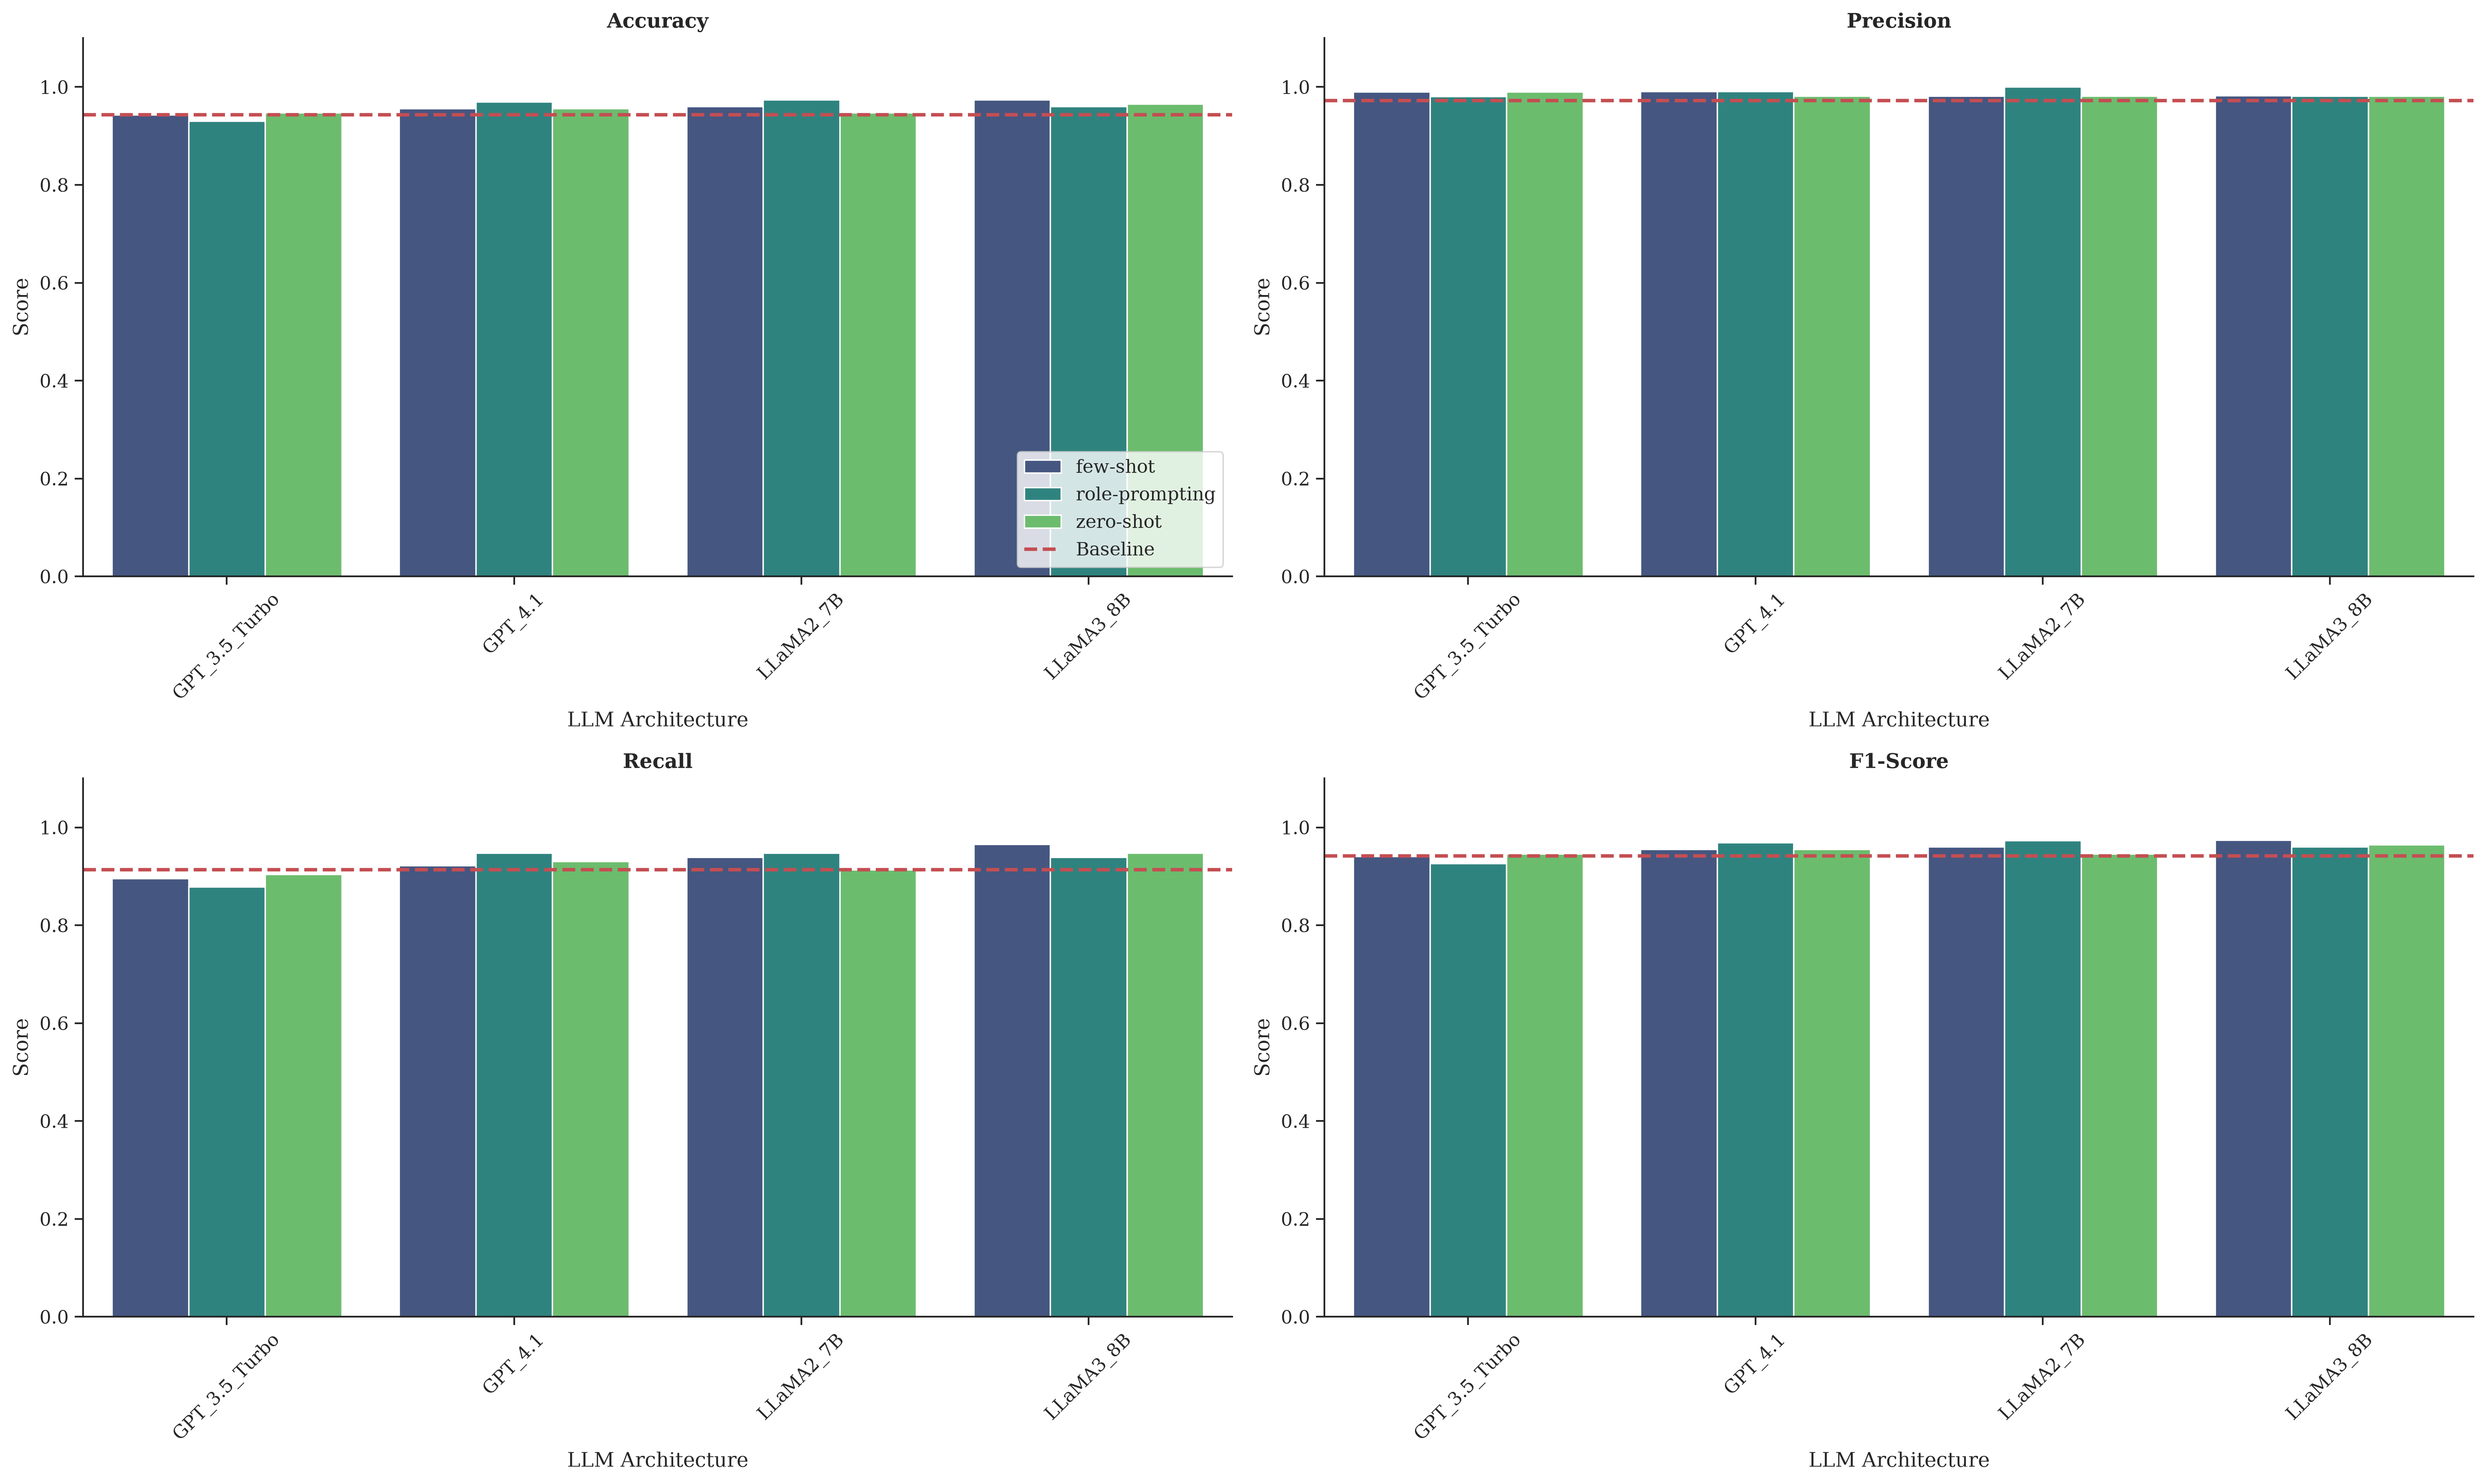

In [7]:
plot_df = df_results[df_results['Model'] != 'Baseline']
baseline_metrics = df_results[df_results['Model'] == 'Baseline'].iloc[0]

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
axes_flat = axes.flatten() 

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for i, metric in enumerate(metrics_to_plot):
    ax = axes_flat[i]
    
    if not plot_df.empty:
        sns.barplot(data=plot_df, x='Model', y=metric, hue='Technique', ax=ax, palette='viridis')
        
    ax.axhline(y=baseline_metrics[metric], color='r', linestyle='--', linewidth=2, label=f'Baseline')
    
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel('Score')
    ax.set_xlabel('LLM Architecture')
    
    legend = ax.get_legend()
    if i == 0:
        if legend is not None:
            ax.legend(loc='lower right')
    else:
        if legend is not None:
            legend.remove()


plt.tight_layout()
plt.show()

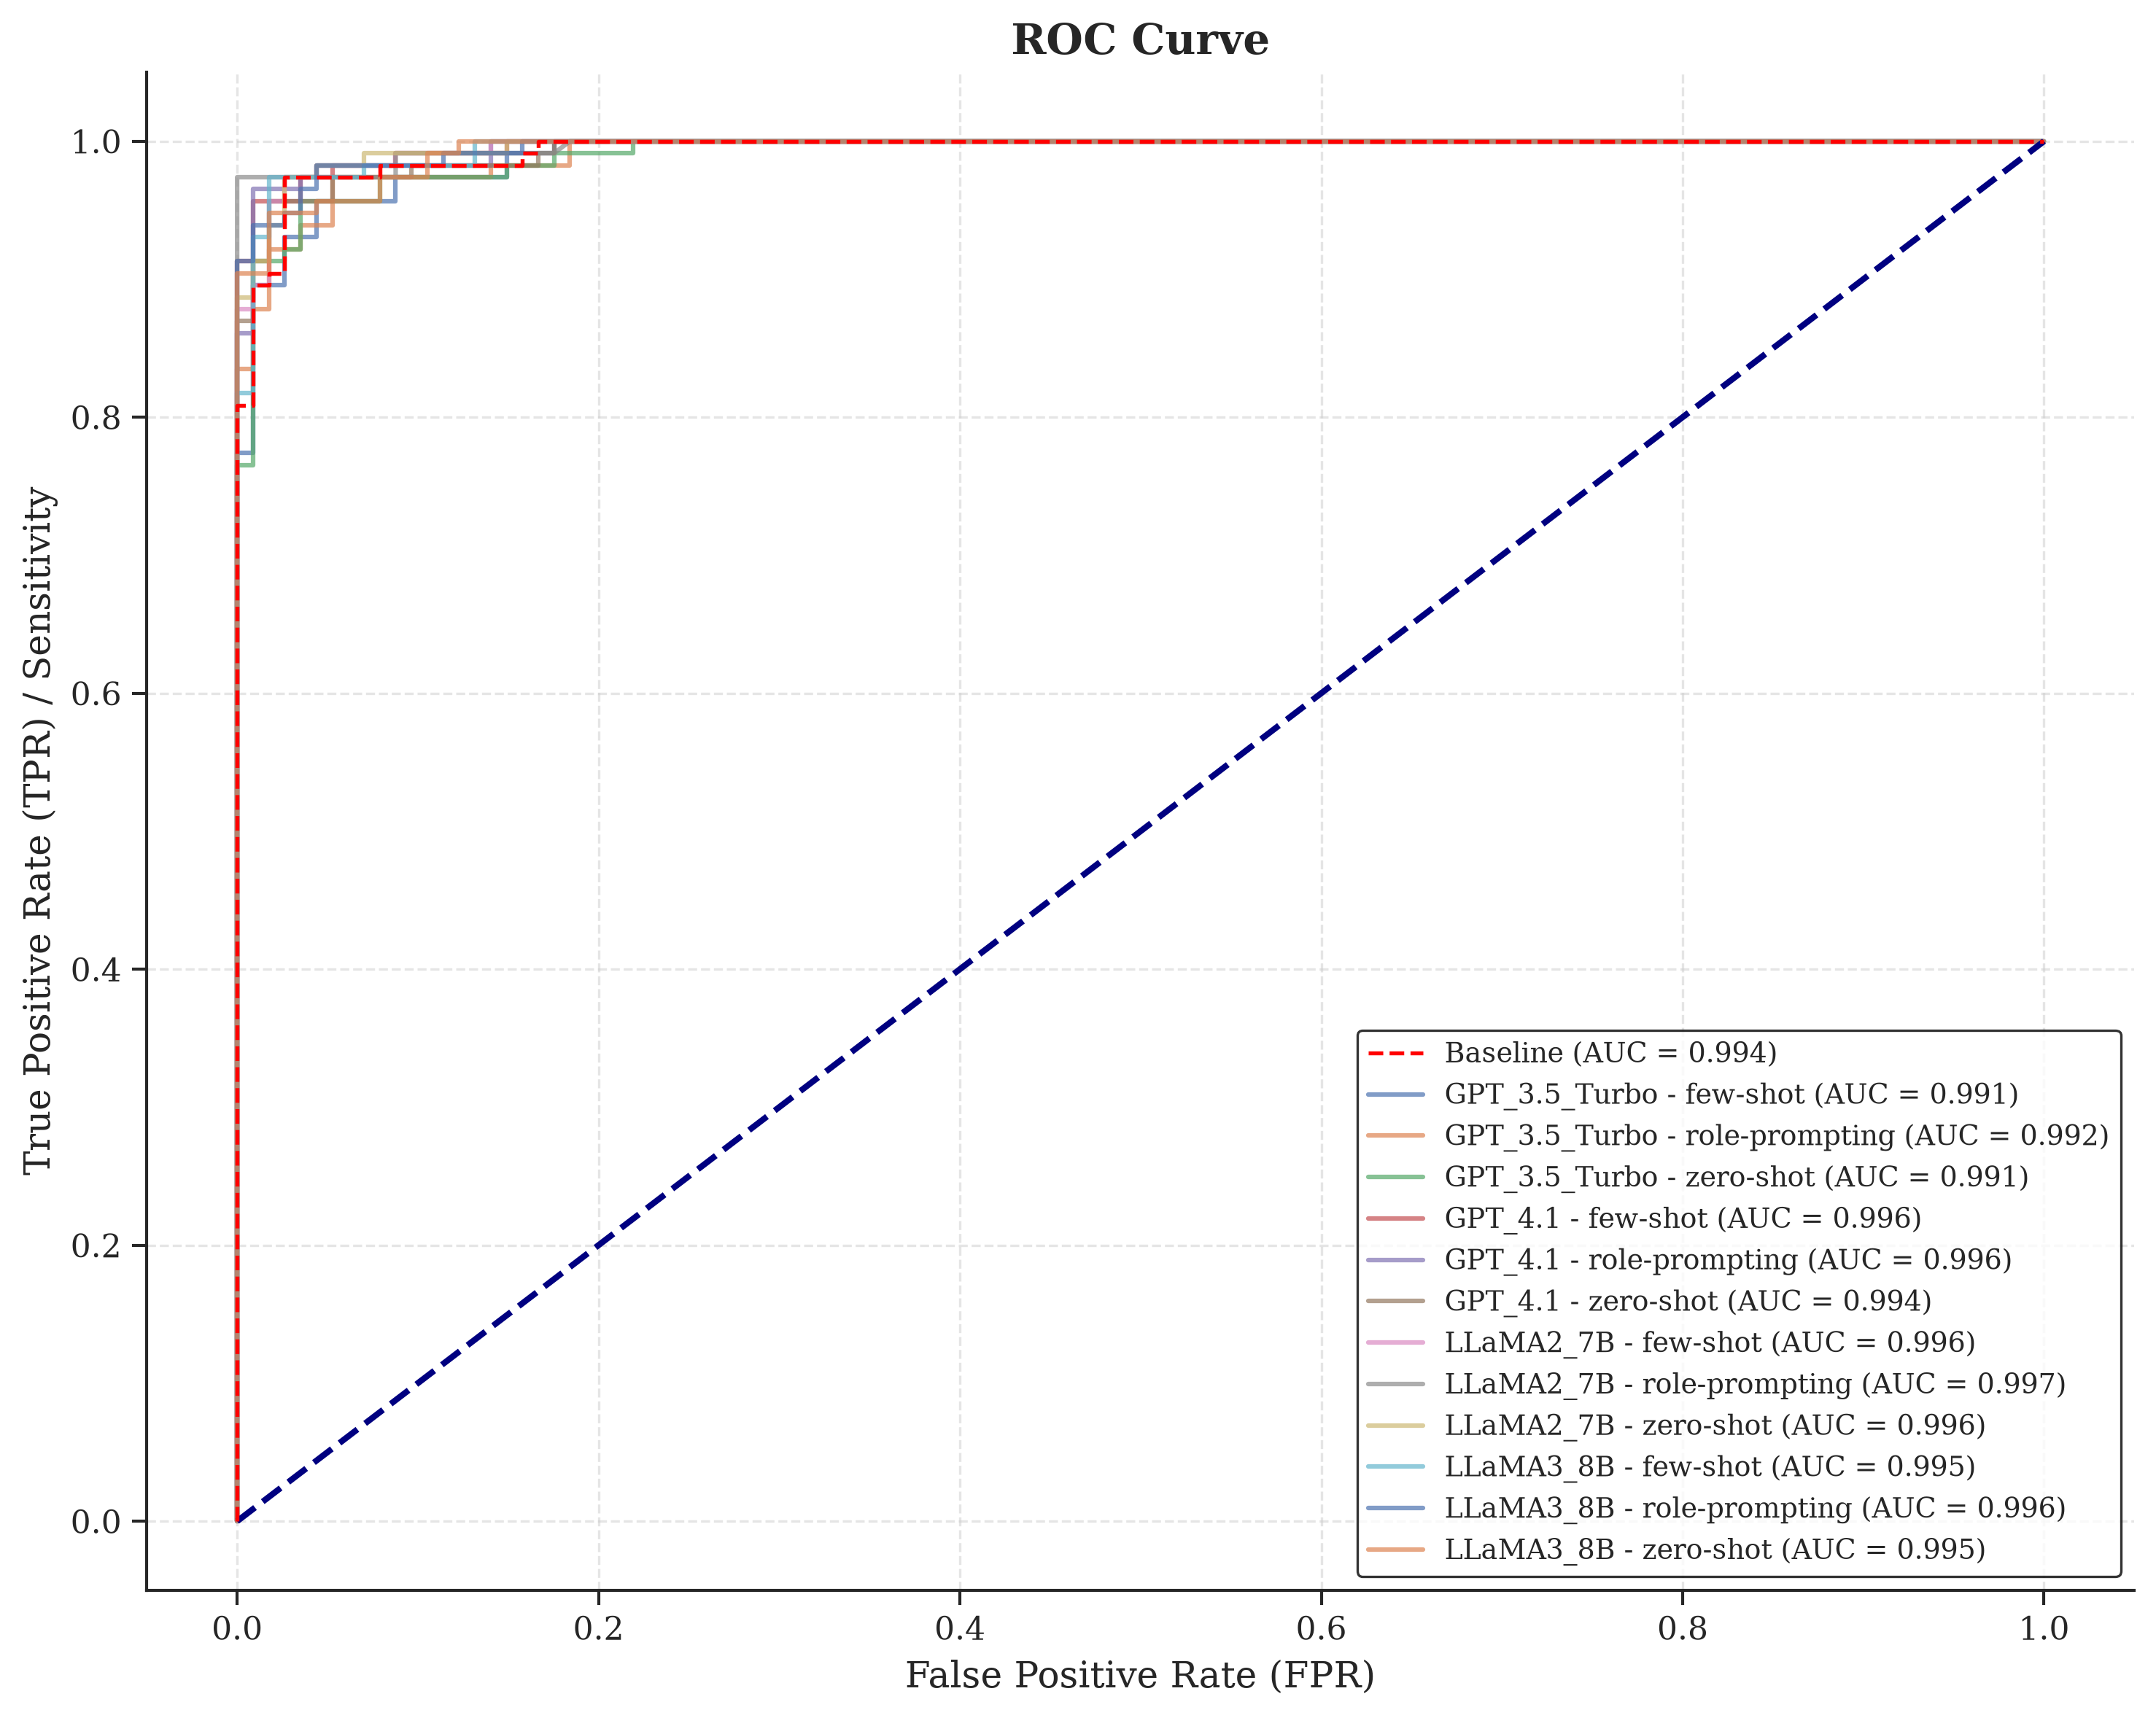

In [8]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

for idx, row in df_results.iterrows():
    fpr, tpr, thresholds = roc_curve(row['y_test'], row['y_prob'])
    auc_score = row['ROC-AUC']
    
    if row['Model'] == 'Baseline':
        label = f"Baseline (AUC = {auc_score:.3f})"
        plt.plot(fpr, tpr, label=label, color='red', linestyle='--', linewidth=1.3, zorder=10)
    else:
        label = f"{row['Model']} - {row['Technique']} (AUC = {auc_score:.3f})"

        plt.plot(fpr, tpr, label=label, linewidth=1.5, alpha=0.7)

plt.plot([0, 1], [0, 1], color='navy', linestyle='--', linewidth=2)


plt.title('ROC Curve', fontweight='bold', fontsize=14)
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR) / Sensitivity', fontsize=12)

plt.legend(loc='lower right', fontsize=9, frameon=True, edgecolor='black')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [9]:
import os
import glob
import pandas as pd
from src.evaluator import TextEvaluator

print("Initializing NLP Evaluator (Loading BERT and ROUGE models)...")
evaluator = TextEvaluator()

quality_results = []
log_dir = os.path.join(root_dir, "data", "augmented", TIMESTAMP_FOLDER, "augmented_log")

if not os.path.exists(log_dir):
    print(f"Error: Log directory not found -> {log_dir}")
else:
    log_files = glob.glob(os.path.join(log_dir, "log_*.csv"))
    print(f"Found {len(log_files)} log files for NLP evaluation.")
    
    for file_path in log_files:
        file_name = os.path.basename(file_path).replace("log_", "").replace(".csv", "")
        parts = file_name.split("_")
        technique = parts[-1] 
        model_name = "_".join(parts[:-1])
        
        df_log = pd.read_csv(file_path)
        
        original_col = 'original_text' if 'original_text' in df_log.columns else df_log.columns[0]
        synthetic_col = 'augmented_text' if 'augmented_text' in df_log.columns else df_log.columns[1]
        
        df_synthetic = pd.DataFrame({'Pesan': df_log[synthetic_col]})
        original_texts = df_log[original_col].tolist()
        
        print(f"Evaluating text quality for: {model_name} | {technique}")
        
        df_scored, avg_scores = evaluator.evaluate_dataframe(df_synthetic, original_texts)
        
        quality_results.append({
            'Model': model_name,
            'Technique': technique,
            'BERTScore': avg_scores['Avg_BERT_Score'],
            'BLEU': avg_scores['Avg_BLEU'],
            'ROUGE-L': avg_scores['Avg_ROUGE_L']
            # 'Cosine Similarity': avg_scores.get('Avg_Cosine_Sim', None)
        })

df_quality = pd.DataFrame(quality_results)
if not df_quality.empty:
    display(df_quality.round(4).style.background_gradient(cmap='Greens'))

c:\LLM_scam\code\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Initializing NLP Evaluator (Loading BERT and ROUGE models)...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6630.23it/s]


Found 12 log files for NLP evaluation.
Evaluating text quality for: GPT_3.5_Turbo | few-shot


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6118.54it/s]
[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Evaluating text quality for: LLaMA3_8B | role-prompting


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9167.73it/s]
[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Evaluating text quality for: LLaMA3_8B | zero-shot


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9045.91it/s]
[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,Model,Technique,BERTScore,BLEU,ROUGE-L
0,GPT_3.5_Turbo,few-shot,0.780200,0.147400,0.479200
1,GPT_3.5_Turbo,role-prompting,0.761900,0.118100,0.412100
2,GPT_3.5_Turbo,zero-shot,0.776900,0.144500,0.452500
3,GPT_4.1,few-shot,0.804700,0.135300,0.489500
4,GPT_4.1,role-prompting,0.798500,0.114600,0.454000
5,GPT_4.1,zero-shot,0.802100,0.120400,0.471200
6,LLaMA2_7B,few-shot,0.790800,0.334400,0.505100
7,LLaMA2_7B,role-prompting,0.794200,0.367900,0.552300
8,LLaMA2_7B,zero-shot,0.810900,0.392400,0.597400
9,LLaMA3_8B,few-shot,0.818100,0.248700,0.599400


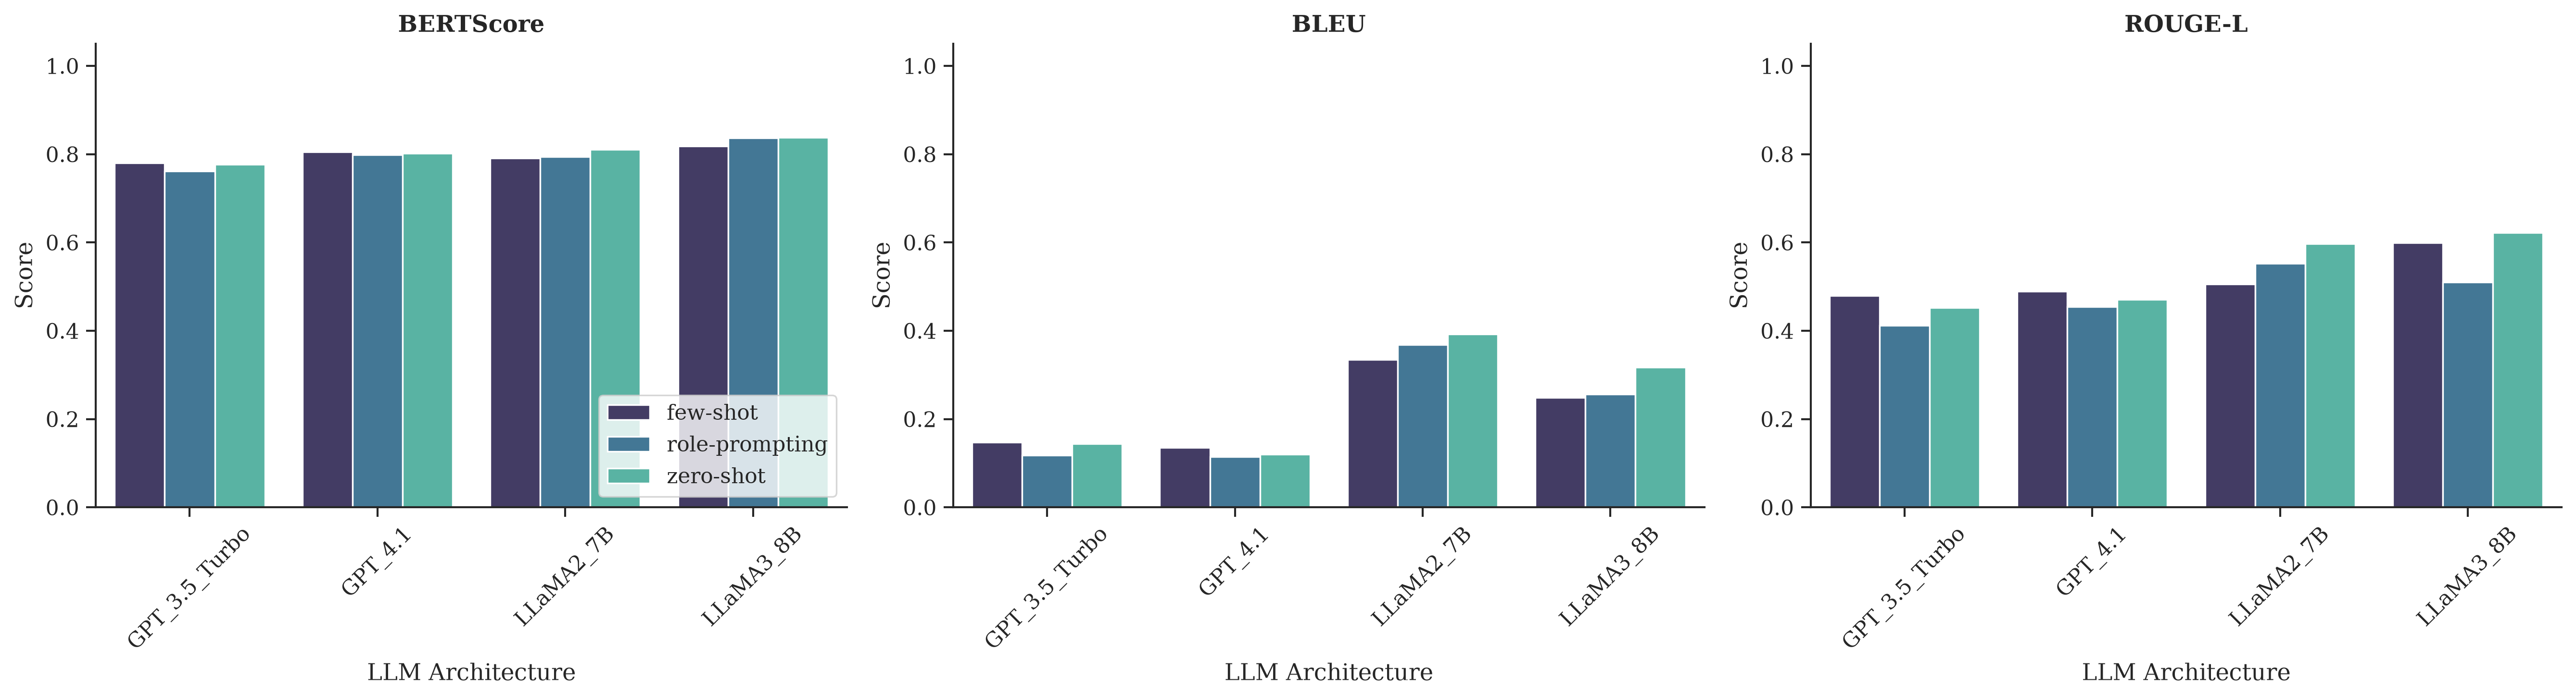

In [10]:
if not df_quality.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    nlp_metrics = ['BERTScore', 'BLEU', 'ROUGE-L']
    
    for i, metric in enumerate(nlp_metrics):
        sns.barplot(data=df_quality, x='Model', y=metric, hue='Technique', ax=axes[i], palette='mako')
        
        axes[i].set_title(metric, fontweight='bold')
        axes[i].set_ylim(0, 1.05) # Text metrics are strictly 0.0 to 1.0
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].set_ylabel('Score')
        axes[i].set_xlabel('LLM Architecture')
        
        legend = axes[i].get_legend()
        if i == 0:
            if legend is not None:
                axes[i].legend(loc='lower right')
        else:
            if legend is not None:
                legend.remove()

    plt.tight_layout()
    plt.show()